# M3A5 - Detecção de objetos

Na prática de hoje vamos utilizar um modelo pré-treinado para detecção de objetos. Para a prática de hoje iremos utilizar a biblioteca  [Ultralytics](https://docs.ultralytics.com/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Detecção de Objetos
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install ultralytics

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 4.3 MB/s  0:00:00
   ---------------------------------------- 0.0/836.9 kB ? eta -:--:--
   ---------------------------------------- 836.9/836.9 kB 3.8 MB/s  0:00:00
   ---------------------------------------- 0.0/52.7 MB ? eta -:--:--
    --------------------------------------- 0.8/52.7 MB 4.2 MB/s eta 0:00:13
   - -------------------------------------- 1.8/52.7 MB 4.7 MB/s eta 0:00:11
   -- ------------------------------------- 3.1/52.7 MB 5.4 MB/s eta 0:00:10
   --- ------------------------------------ 5.0/52.7 MB 6.3 MB/s eta 0:00:08
   ----- ---------------------------------- 6.8/52.7 MB 6.9 MB/s eta 0:00:07
   ------ --------------------------------- 8.9/52.7 MB 7.5 MB/s eta 0:00:06
   -------- ------------------------------- 11.0/52.7 MB 7.9 MB/s eta 0:00:06
   ---------- ----------

Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
import ultralytics


In [3]:
# TODO Atualize o path da imagem.
image = cv2.imread("street.jpeg")

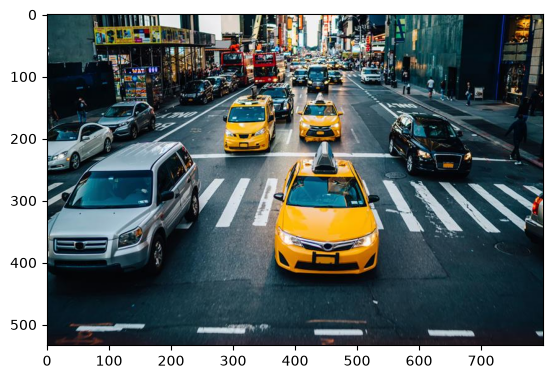

In [4]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Detecção de Objetos

Iremos carregar o modelo pré treinado e visualizar seus resultados.


0: 448x640 4 persons, 15 cars, 1 bus, 76.0ms
Speed: 4.3ms preprocess, 76.0ms inference, 20.3ms postprocess per image at shape (1, 3, 448, 640)


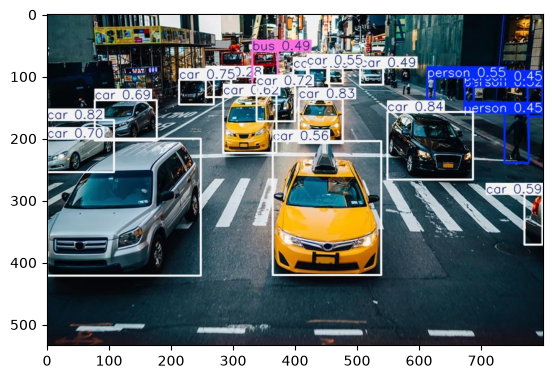

In [5]:
# Load a pretrained YOLO11n model
model = ultralytics.YOLO("yolo11n.pt")

# Roda a inferência do modelo YOLO.
results = model(image)

for i, result in enumerate(results):
    # Salva os resultados em uma imagem no disco.
    result.save(filename=f"results_{i}.jpg")

# Carrega a imagem que acabou de ser salva para visualizarmos.
results_image = cv2.imread("results_0.jpg")
plt.imshow(cv2.cvtColor(results_image, cv2.COLOR_BGR2RGB))

E basta isso para detectarmos objetos que a [YOLO](https://arxiv.org/pdf/1506.02640) foi treinada para detectar.

## Próximos Passos e Referências

Nas próximas práticas iremos ver outras tarefas clássicas de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://docs.ultralytics.com/
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [ ] Explore a biblioteca e tente rodar o modelo utilizando linha de comando e com outras opções.

In [9]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Carrega o modelo
model = YOLO("yolo11n.pt")

In [8]:
# Lê a imagem
image = cv2.imread("street.jpeg")

In [11]:
# Faz a inferência
results = model(image)


0: 448x640 4 persons, 15 cars, 1 bus, 15.5ms
Speed: 2.8ms preprocess, 15.5ms inference, 3.5ms postprocess per image at shape (1, 3, 448, 640)


In [12]:
# Classe "car" no COCO
CAR_CLASS = 2

In [13]:
for result in results:

    boxes = result.boxes

    for box in boxes:

        cls = int(box.cls[0])

        # Apenas carros
        if cls != CAR_CLASS:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Recorta o carro
        carro = image[y1:y2, x1:x2]

        # Converte para HSV
        hsv = cv2.cvtColor(carro, cv2.COLOR_BGR2HSV)

        # Faixa de amarelo
        lower = np.array([20, 100, 100])
        upper = np.array([35, 255, 255])

        mask = cv2.inRange(hsv, lower, upper)

        # Percentual de pixels amarelos
        porcentagem = cv2.countNonZero(mask) / mask.size

        # Se tiver bastante amarelo, considera carro amarelo
        if porcentagem > 0.15:

            cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.putText(image,
                        "Carro amarelo",
                        (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        (0,255,0),
                        2)


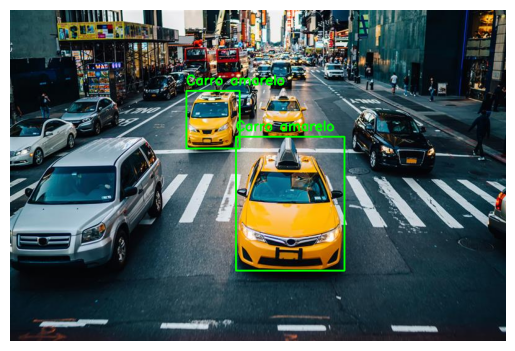

In [14]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()